In [1]:
import torch
import torch.optim as optim
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import sys
sys.path.append('../')

from models.vgg_extractor import VGGFeatureExtractor
from utils.losses import content_loss, style_loss


In [2]:
vgg = VGGFeatureExtractor()

x = torch.randn(1, 3, 256, 256)

features = vgg(x)

print(f"Feature estratte: {features.keys()}")
for name, feat in features.items():
    print(f"{name}: {feat.shape}")

d:\Project\pytorch-fundamental\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Project\pytorch-fundamental\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Feature estratte: dict_keys(['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv4_2', 'conv5_1'])
conv1_1: torch.Size([1, 64, 256, 256])
conv2_1: torch.Size([1, 128, 128, 128])
conv3_1: torch.Size([1, 256, 64, 64])
conv4_1: torch.Size([1, 512, 32, 32])
conv4_2: torch.Size([1, 512, 32, 32])
conv5_1: torch.Size([1, 512, 16, 16])


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg = VGGFeatureExtractor().to(device).eval()

style_layers = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

# Hyperparameters
alpha = 1e7  # peso per content
beta = 1e0   # peso per style
num_steps = 5000
lr = 0.01

In [ ]:
def load_image(path, max_size=512):
    """Carica e preprocessa un'immagine"""
    image = Image.open(path).convert('RGB')
    
    size = max(image.size)
    scale = max_size / size
    new_size = tuple(int(dim * scale) for dim in image.size)
    image = image.resize(new_size, Image.LANCZOS)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    return transform(image).unsqueeze(0)  # aggiungi batch dimension

In [6]:
content_img = load_image('../images/content/cat.jpg').to(device)
style_img = load_image('../images/style/starry_night.jpg').to(device)

with torch.no_grad():
    content_features = vgg(content_img)
    style_features = vgg(style_img)

gen_img = content_img.clone().requires_grad_(True)

optimizer = optim.Adam([gen_img], lr=lr)

In [7]:
for step in range(num_steps):
    # 1. Estrai feature dall'immagine generata
    gen_features = vgg(gen_img)
    
    # 2. Calcola le loss
    c_loss = content_loss(gen_features, content_features)
    s_loss = style_loss(gen_features, style_features, style_layers)
    total_loss = alpha * c_loss + beta * s_loss
    
    # 3. Backward
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # 4. Clamp pixels nel range valido
    with torch.no_grad():
        gen_img.clamp_(0, 1)
    
    # 5. Print progress
    if step % 50 == 0:
        print(f"Step {step}/{num_steps}")
        print(f"  Content: {c_loss.item():.2f}, Style: {s_loss.item():.2f}, Total: {total_loss.item():.2f}")

print("Optimization complete!")

Step 0/5000
  Content: 0.00, Style: 379392992.00, Total: 379392992.00
Step 50/5000
  Content: 0.81, Style: 17184678.00, Total: 25298520.00
Step 100/5000
  Content: 0.65, Style: 9491287.00, Total: 15942550.00
Step 150/5000
  Content: 0.57, Style: 5519246.50, Total: 11240812.00
Step 200/5000
  Content: 0.52, Style: 3894159.50, Total: 9130150.00
Step 250/5000
  Content: 0.49, Style: 3445211.75, Total: 8347858.00
Step 300/5000
  Content: 0.47, Style: 3271269.50, Total: 7937688.00
Step 350/5000
  Content: 0.45, Style: 3164668.00, Total: 7653078.00
Step 400/5000
  Content: 0.43, Style: 3090755.50, Total: 7434450.50
Step 450/5000
  Content: 0.42, Style: 3039709.50, Total: 7256410.00
Step 500/5000
  Content: 0.41, Style: 3000231.75, Total: 7099789.00
Step 550/5000
  Content: 0.40, Style: 2965519.00, Total: 6965958.00
Step 600/5000
  Content: 0.39, Style: 2934303.50, Total: 6856137.50
Step 650/5000
  Content: 0.39, Style: 2908393.50, Total: 6764215.00
Step 700/5000
  Content: 0.38, Style: 28861

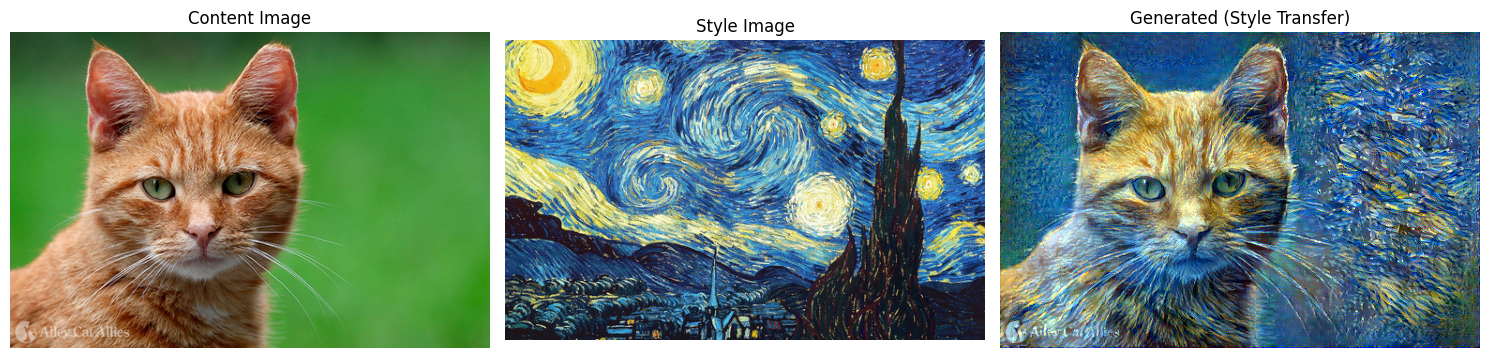

In [8]:
# Dopo "Optimization complete!"
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def tensor_to_image(tensor):
    img = tensor.squeeze().detach().cpu().permute(1, 2, 0).numpy()
    return img.clip(0, 1)

axes[0].imshow(tensor_to_image(content_img))
axes[0].set_title('Content Image')
axes[0].axis('off')

axes[1].imshow(tensor_to_image(style_img))
axes[1].set_title('Style Image')
axes[1].axis('off')

axes[2].imshow(tensor_to_image(gen_img))
axes[2].set_title('Generated (Style Transfer)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../results/style_transfer_result.png', dpi=300, bbox_inches='tight')
plt.show()